In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import seaborn as sns

# For venn diagram
from matplotlib_venn import venn3, venn2
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based


plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6

In [2]:
colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


cat_colors_map = dict(zip(unique_categories, colors_list))                  
cat_labels_map = dict(zip(unique_categories, unique_categories))


filtering_set = ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']
filtering_set_labels = ['CR droplets', 'SADE droplets', 'TSSe nuclei']
filtering_set_label_map = dict(zip(filtering_set, filtering_set_labels))

jitter_width = 0.25
position_offset = [0] + [-jitter_width] * 3 + [jitter_width] * 3  # Adjust offsets for each category
cat_position_map = dict(zip(unique_categories, position_offset))

In [3]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 2 + [jitter_width] * 2  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))


SADEvsCR_filteringset = [ 'atac_pass_CR', 'atac_pass_entropy',]

In [4]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1, norm=None):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    try:
        ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors, norm=norm) # s controls point size
    except Exception:
        ax.scatter(x_jittered, data_group, c=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, norm=norm) # fallback without edgecolors for older matplotlib versions

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [ ]:
data_set_name = 'mice_brain_5k'

entropy_dir ='/mnt/hdd_bob/syy/adipose/atac/res/mice_brain_5k_WS3000/'

entropy_all_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
print(entropy_df.shape) 
entropy_df.head(2)

(5847, 8)


,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
AAGTTAGCAGCATTAT-1,0.008518,0.805091,9,0.214556,0.806900,0.999285,NO,AAGTTAGCAGCATTAT
AATGTCATCCCTGGAA-1,0.394244,0.141553,100,0.019934,0.980264,0.922239,NO,AATGTCATCCCTGGAA


In [7]:
# Load filtered barcodes from each filtering method
sade_bcs= os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
cr_bcs = os.path.join(entropy_dir, '_CR_FRIP', 'barcodes.tsv')
tss_bcs = os.path.join(entropy_dir, '_ArchR_TSS', 'QualityControl/mice_brain_5k_Metadata.tsv')

sade_bc_df = pd.read_csv(sade_bcs, sep=',', index_col=0)
cr_bcs_df = pd.read_csv(cr_bcs, sep='\t', index_col=0, header=None)
cr_bcs_df.index.name = 'atac_barcodes'
tss_bcs_df = pd.read_csv(tss_bcs, sep='\t', index_col=0)
tss_bcs_df['atac_barcodes'] = tss_bcs_df.index.map(lambda x: x.split('#')[1])


In [8]:
tss_bcs_df.head(2)

,nFrags,nMonoFrags,nDiFrags,nMultiFrags,TSSEnrichment,ReadsInTSS,Keep,ReadsInPromoter,PromoterRatio,ReadsInBlacklist,BlacklistRatio,atac_barcodes
cellNames,,,,,,,,,,,,
mice_brain_5k#GACCGTTCACAGGAAT-1,97222,34960,37589,24673,16.061,10593,1,39649,0.203910,3020,0.015531,GACCGTTCACAGGAAT-1
mice_brain_5k#AGAGAGGAGGTTTGCG-1,96314,38189,35939,22186,14.766,9828,1,37788,0.196171,2881,0.014956,AGAGAGGAGGTTTGCG-1


In [9]:
# create union cell set by combining three filtering sets
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
os.mkdir(Union_cell_subdir) if not os.path.exists(Union_cell_subdir) else None
tosave_union_cell_set = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')


# Load fragments file
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_bc'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_barcodes'] = frag.index
      

total_frag = frag.groupby('atac_barcodes').size().rename('total_fragments')
total_frag_df = total_frag.to_frame()


total_frag_df['atac_pass_CR'] = total_frag_df.index.isin(cr_bcs_df.index)
total_frag_df['atac_pass_entropy'] = total_frag_df.index.isin(sade_bc_df.index)
total_frag_df['atac_pass_archr_TSS'] = total_frag_df.index.isin(tss_bcs_df['atac_barcodes'])


total_frag_df['_2set_identified_by_atac_SC'] = total_frag_df.apply(lambda row: 'both' if row['atac_pass_CR'] and row['atac_pass_entropy'] else ('entropy_only' if row['atac_pass_entropy'] else ('cr_only' if row['atac_pass_CR'] else ('entropy_only' if row['atac_pass_entropy'] else 'none'))), axis=1)
total_frag_df['_2set_identified_by_atac_ST'] = total_frag_df.apply(lambda row: 'both' if row['atac_pass_archr_TSS'] and row['atac_pass_entropy'] else ('tss_only' if row['atac_pass_archr_TSS'] else ('entropy_only' if row['atac_pass_entropy']  else 'none')), axis=1)


total_frag_df.loc[total_frag_df['atac_pass_CR'] & total_frag_df['atac_pass_entropy'] & total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'common'
total_frag_df.loc[total_frag_df['atac_pass_CR'] & total_frag_df['atac_pass_entropy'] & ~total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'SADE+CR, not TSS'
total_frag_df.loc[~total_frag_df['atac_pass_CR'] & total_frag_df['atac_pass_entropy'] & total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'SADE+TSS, not CR'
total_frag_df.loc[total_frag_df['atac_pass_CR'] & ~total_frag_df['atac_pass_entropy'] & total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'CR+TSS, not SADE'  
total_frag_df.loc[total_frag_df['atac_pass_entropy'] & ~total_frag_df['atac_pass_CR'] & ~total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'SADE unique'
total_frag_df.loc[total_frag_df['atac_pass_CR'] & ~total_frag_df['atac_pass_entropy'] & ~total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'CR unique'
total_frag_df.loc[~total_frag_df['atac_pass_CR'] & ~total_frag_df['atac_pass_entropy'] & total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'TSS unique'
total_frag_df.loc[~total_frag_df['atac_pass_CR'] & ~total_frag_df['atac_pass_entropy'] & ~total_frag_df['atac_pass_archr_TSS'],'_3set_identified_by_atac'] = 'none'

for col in ['Entropy', 'DNA_debris', 'P_closed_state']:
    total_frag_df[col] = total_frag_df.index.map(lambda x: entropy_df.loc[x, col] if x in entropy_df.index else np.nan)

total_frag_df.to_csv(tosave_union_cell_set, sep='\t')

In [10]:
total_frag_df.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state
atac_barcodes,,,,,,,,,,
AAACAGCCAAACAACA-1,1,False,False,False,none,none,none,NaN,NaN,NaN
AAACAGCCAAACATAG-1,1,False,False,False,none,none,none,NaN,NaN,NaN


In [11]:
total_frag_df['atac_pass_CR'].sum(), total_frag_df['atac_pass_entropy'].sum(), total_frag_df['atac_pass_archr_TSS'].sum()

(np.int64(4881), np.int64(4858), np.int64(4698))

In [12]:
total_frag_df.groupby('_2set_identified_by_atac_SC').size()

_2set_identified_by_atac_SC
both              4738
cr_only            143
entropy_only       120
none            482056
dtype: int64

In [13]:
total_frag_df.groupby('_2set_identified_by_atac_ST').size()

_2set_identified_by_atac_ST
both              4663
entropy_only       195
none            482164
tss_only            35
dtype: int64

In [14]:
total_frag_df.groupby('_3set_identified_by_atac').size()

_3set_identified_by_atac
CR unique              123
CR+TSS, not SADE        20
SADE unique             64
SADE+CR, not TSS       131
SADE+TSS, not CR        56
TSS unique              15
common                4607
none                482041
dtype: int64

In [15]:
total_frag_df.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state
atac_barcodes,,,,,,,,,,
AAACAGCCAAACAACA-1,1,False,False,False,none,none,none,NaN,NaN,NaN
AAACAGCCAAACATAG-1,1,False,False,False,none,none,none,NaN,NaN,NaN


# Load

In [7]:
# Load union set cells 
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_all_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)


union_cell_all_info['log_entropy'] = np.log2(union_cell_all_info['Entropy'])
union_cell_all_info['log_total_fragments'] = np.log1p(union_cell_all_info['total_fragments'])


union_cell_info = union_cell_all_info.loc[union_cell_all_info['_3set_identified_by_atac'] != 'none'].copy()

union_cell_all_info.shape, union_cell_info.shape

((487057, 12), (5016, 12))

In [8]:
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state,log_entropy,log_total_fragments
atac_barcodes,,,,,,,,,,,,
AAACAGCCAACCGCCA-1,19211,True,True,True,both,both,common,0.406097,NO,0.918889,-1.300103,9.863290
AAACAGCCAAGGTCGA-1,10802,True,True,True,both,both,common,0.415202,NO,0.916268,-1.268113,9.287579


In [9]:
col_list = [ '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac']
col_list += ['total_fragments']
for col in col_list:
    entropy_df[col] = entropy_df.index.map(union_cell_all_info[col]).fillna('none')

entropy_df['log_entropy'] = np.log2(entropy_df['Entropy'])
entropy_df['log_total_fragments'] = np.log1p(entropy_df['total_fragments'])
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,total_fragments,log_entropy,log_total_fragments
AAGTTAGCAGCATTAT-1,0.008518,0.805091,9,0.214556,0.806900,0.999285,NO,AAGTTAGCAGCATTAT,cr_only,none,CR unique,108,-6.875219,4.691348
AATGTCATCCCTGGAA-1,0.394244,0.141553,100,0.019934,0.980264,0.922239,NO,AATGTCATCCCTGGAA,both,both,common,1792,-1.342839,7.491645


In [15]:
frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_raw_peaks.index.name ='atac_barcodes'
frag_in_raw_peaks.columns = ['chrom', 'start', 'end', 'support']

Nfrag_in_rawpeaks = frag_in_raw_peaks.groupby('atac_barcodes').size().rename('N_frag_in_raw_peaks')

union_cell_info['Nfrag_in_rawpeaks'] = union_cell_info.index.map(Nfrag_in_rawpeaks).fillna(0)
union_cell_info['frip_rawpeaks'] = union_cell_info['Nfrag_in_rawpeaks'] / union_cell_info['total_fragments']

In [16]:

union_cell_info['Nfrag_in_rawpeaks'] = union_cell_info.index.map(Nfrag_in_rawpeaks).fillna(0)
union_cell_info['frip_rawpeaks'] = union_cell_info['Nfrag_in_rawpeaks'] / union_cell_info['total_fragments']

In [17]:
# Those in the union set but in neither of CR or SADE are uniquely identified by TSS enrichment
union_cell_info['_2set_identified_by_atac_SC_mod'] = union_cell_info['_2set_identified_by_atac_SC'].replace('none', 'tss_only')

# Venn comparison

In [18]:
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,total_fragments,log_entropy,log_total_fragments
AAGTTAGCAGCATTAT-1,0.008518,0.805091,9,0.214556,0.806900,0.999285,NO,AAGTTAGCAGCATTAT,cr_only,none,CR unique,108,-6.875219,4.691348
AATGTCATCCCTGGAA-1,0.394244,0.141553,100,0.019934,0.980264,0.922239,NO,AATGTCATCCCTGGAA,both,both,common,1792,-1.342839,7.491645


Text(0.5, 1.0, 'mice_brain_5k')

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


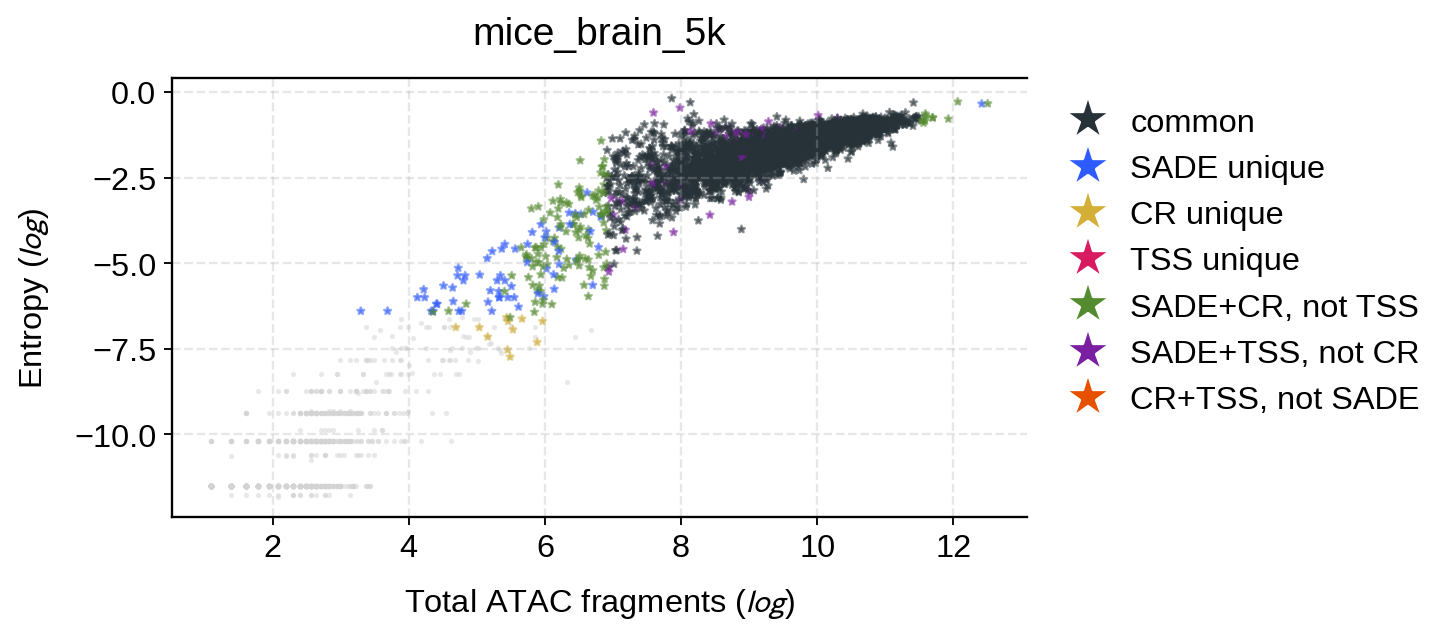

In [19]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

# droplets not in any of the 3 sets are colored in light gray
not_in_any_set = ~entropy_df['atac_bc'].isin(union_cell_info.index)
ax.scatter( entropy_df.loc[not_in_any_set, 'log_total_fragments'], 
            entropy_df.loc[not_in_any_set, 'log_entropy'], 
            c='lightgray',
            marker='o', 
            s=5,
            alpha=0.5,
            lw=0,)
# Now the droplets in the union set are colored by their category 
ax.scatter( union_cell_info['log_total_fragments'], union_cell_info['log_entropy'],  c= union_cell_info['_3set_identified_by_atac'].map(cat_colors_map), 
            alpha=0.5, 
            s=10,          
            lw=1,      
            marker='*',   
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log$)', labelpad=10)
ax.set_ylabel('Entropy ($log$)', labelpad=10)


handles = [Line2D([0], [0], marker='*', color='w', markerfacecolor=v, label=k, markersize=20) for k, v in cat_colors_map.items()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.3)

ax.set_title(data_set_name, pad=15)


_3set_identified_by_atac
CR unique           112
CR+TSS, not SADE     20
TSS unique           15
Name: count, dtype: int64
                          count      mean       std       min       25%  \
_3set_identified_by_atac                                                  
CR unique                 112.0  0.539079  0.074030  0.323077  0.497744   
CR+TSS, not SADE           20.0  0.495544  0.071295  0.353774  0.442145   
TSS unique                 15.0  0.093319  0.088054  0.027536  0.044963   

                               50%       75%       max  
_3set_identified_by_atac                                
CR unique                 0.534843  0.582708  0.691667  
CR+TSS, not SADE          0.493488  0.538622  0.619772  
TSS unique                0.059589  0.097441  0.356836  


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


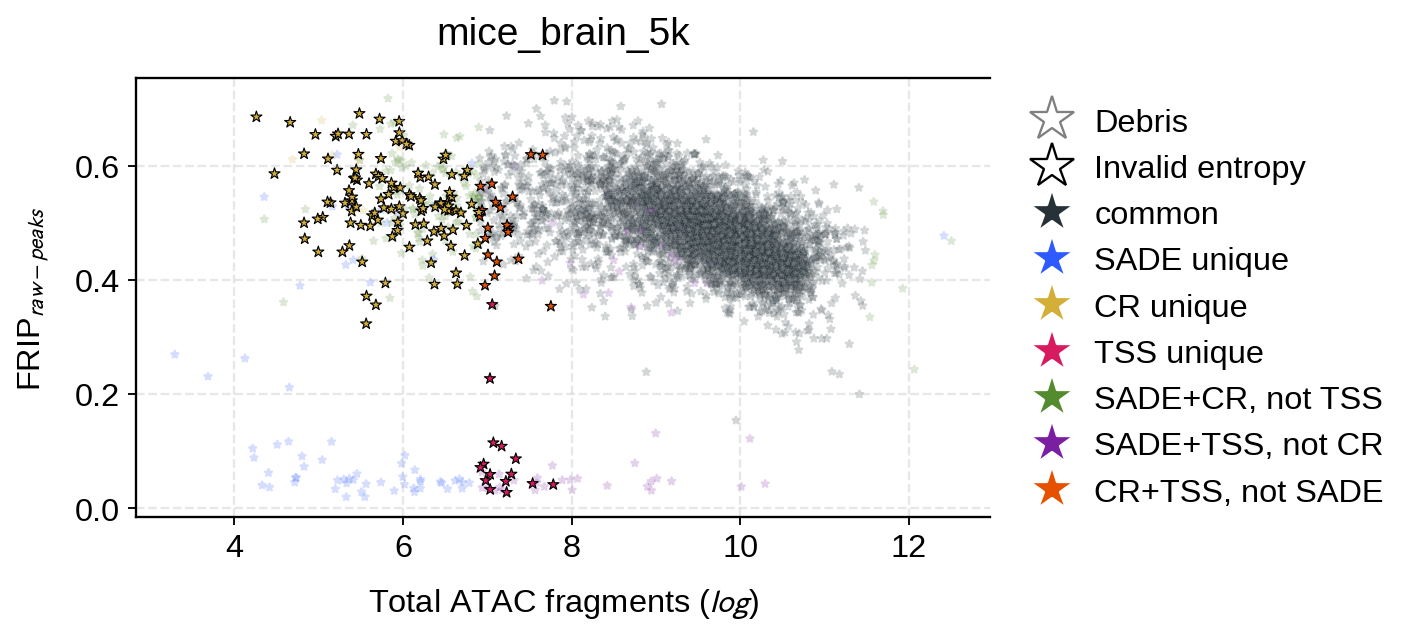

In [20]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

dna_debris_index = union_cell_info['DNA_debris'] == 'YES'
invalid_entropy_index = union_cell_info['Entropy'].isna()

# Only the droplets in the union set are colored by their category 
## For non-DNA-debris droplets, color by their category
ax.scatter( union_cell_info.loc[(~dna_debris_index) & (~invalid_entropy_index), 'log_total_fragments'], union_cell_info.loc[(~dna_debris_index) & (~invalid_entropy_index), 'frip_rawpeaks'],  edgecolors= union_cell_info.loc[(~dna_debris_index) & (~invalid_entropy_index), '_3set_identified_by_atac'].map(cat_colors_map), 
            c='white', alpha=0.2, 
            s=10,          
            lw=1,      
            marker='*', 
              
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For DNA-debris droplets, edgecolor in black 
ax.scatter( union_cell_info.loc[dna_debris_index, 'log_total_fragments'], union_cell_info.loc[dna_debris_index, 'frip_rawpeaks'],  c= union_cell_info.loc[dna_debris_index, '_3set_identified_by_atac'].map(cat_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.5,      
            marker='*',   
            edgecolors='grey',
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For droplets with invalid entropy, edgecolor in red 
ax.scatter( union_cell_info.loc[invalid_entropy_index, 'log_total_fragments'], union_cell_info.loc[invalid_entropy_index, 'frip_rawpeaks'],  c= union_cell_info.loc[invalid_entropy_index, '_3set_identified_by_atac'].map(cat_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.5,      
            marker='*',   
            edgecolors='black',
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log$)', labelpad=10)
ax.set_ylabel('FRIP$_{raw-peaks}$', labelpad=10)


handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none',  label='Debris', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none',  label='Invalid entropy', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w', markerfacecolor=v, label=k, markersize=20) for k, v in cat_colors_map.items()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.3)
ax.set_title(data_set_name, pad=15)


print(
union_cell_info.loc[invalid_entropy_index, '_3set_identified_by_atac'].value_counts()
)
print(
union_cell_info.loc[invalid_entropy_index].groupby('_3set_identified_by_atac')['frip_rawpeaks'].describe()
)

Text(0.5, 1.0, 'mice_brain_5k')

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


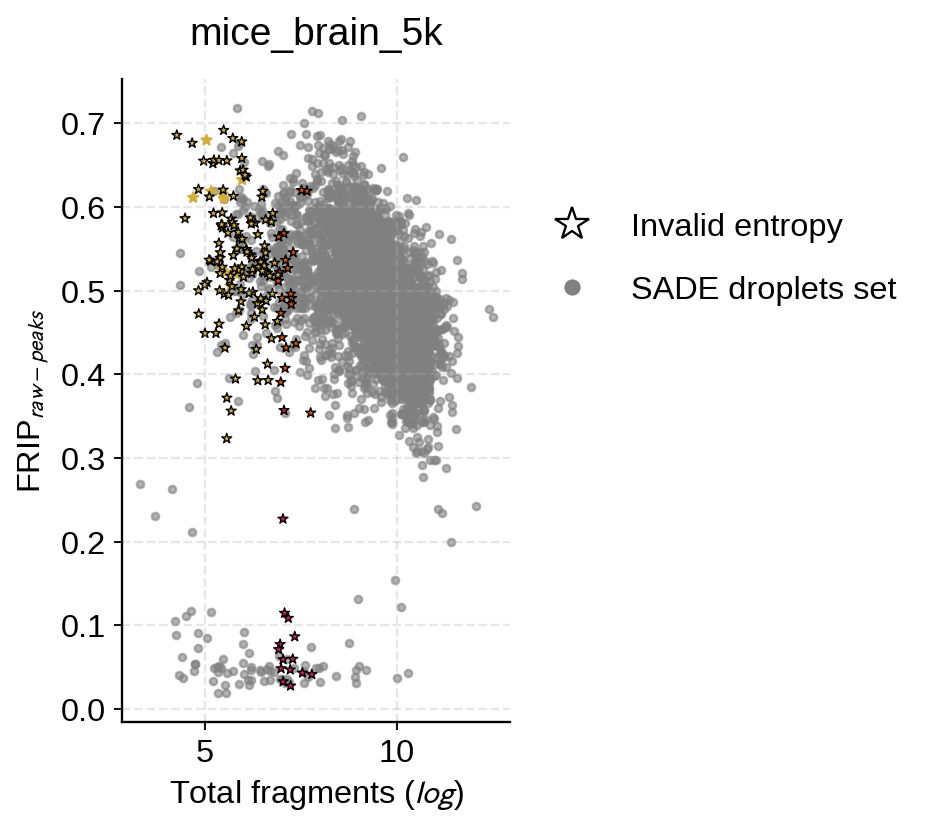

In [21]:

fig = plt.figure(layout="constrained", figsize=(6.6, 5))

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
ax = plt.subplot(gs[1])


not_in_entropy_set = ~union_cell_info['atac_pass_entropy']
invalid_entropy_set = union_cell_info['Entropy'].isna()
# SADE droplets 
ax.scatter( union_cell_info.loc[ (~not_in_entropy_set) , 'log_total_fragments'], union_cell_info.loc[(~not_in_entropy_set) , 'frip_rawpeaks'],  c= 'grey',
            alpha=0.6, 
            s=10,          
            lw=1,      
            marker='o',   
            rasterized=True # Keeps the file size light if saving to PDF
                )
# not in SADE but valid entropy values 
ax.scatter( union_cell_info.loc[not_in_entropy_set & (~invalid_entropy_set) , 'log_total_fragments'], 
            union_cell_info.loc[not_in_entropy_set & (~invalid_entropy_set), 'frip_rawpeaks'], 
            c=union_cell_info.loc[not_in_entropy_set & (~invalid_entropy_set), '_3set_identified_by_atac'].map(cat_colors_map),
            marker='*', 
            s=20,
            alpha=1,
            lw=1,)
# not in SADE and invalid entropy values
ax.scatter( union_cell_info.loc[not_in_entropy_set & invalid_entropy_set, 'log_total_fragments'], union_cell_info.loc[not_in_entropy_set & invalid_entropy_set, 'frip_rawpeaks'], 
           c=union_cell_info.loc[not_in_entropy_set & (invalid_entropy_set), '_3set_identified_by_atac'].map(cat_colors_map),
           edgecolors='black',
           #c='black',
            alpha=1, 
            s=20,          
            lw=0.6,      
            marker='*',   
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)')
ax.set_ylabel('FRIP$_{raw-peaks}$', )

droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Invalid entropy', markersize=15),]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.7) )
ax.add_artist(leg2)  

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', label='SADE droplets set', markersize=8)] 
# handles += [Line2D([0], [0], marker='*', color='w', markerfacecolor=cat_colors_map[k], label=k, markersize=20) for k in (union_cell_info['_3set_identified_by_atac'][not_in_entropy_set]).unique()]
ax.legend(handles=handles, 
             frameon=False, bbox_to_anchor=(1, 0.74), loc='upper left', ncol=1, )

ax.set_title(data_set_name, pad=15)


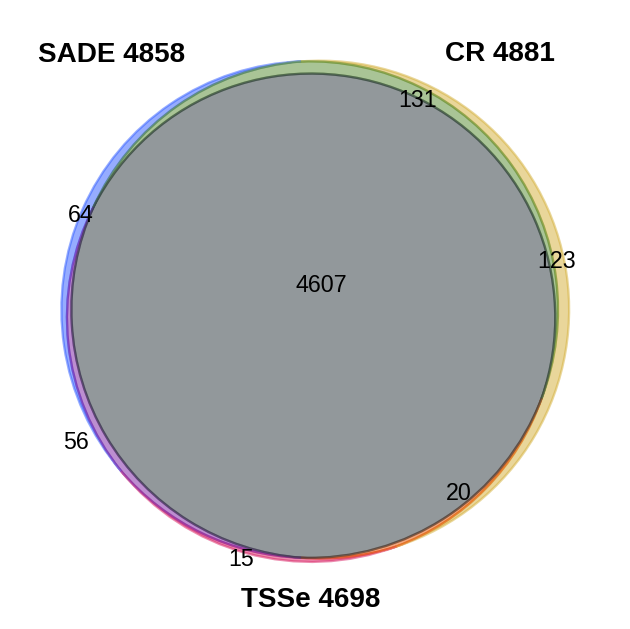

In [22]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
)

# fixed_sizes = (0.4, 0.3, 0.4, 0.3, 0.4, 0.2, 0.2) 

fig, ax = plt.subplots(figsize=(4, 4))
v = venn3(venn_sets, set_labels=[f'SADE {union_cell_info[union_cell_info["atac_pass_entropy"]].shape[0]}', 
                                 f'CR {union_cell_info[union_cell_info["atac_pass_CR"]].shape[0]}', 
                                 f'TSSe {union_cell_info[union_cell_info["atac_pass_archr_TSS"]].shape[0]}'], 
             ax=ax, )


v.get_patch_by_id('100').set_color('#2E5BFF') # Set A
v.get_patch_by_id('010').set_color('#D4AF37') # Set B
v.get_patch_by_id('001').set_color('#D81B60') # Set C

v.get_patch_by_id('110').set_color('#558B2F') # A & B (Green)
v.get_patch_by_id('011').set_color('#E65100') # B & C (Purple)
v.get_patch_by_id('101').set_color('#7B1FA2') # A & C (Orange)
v.get_patch_by_id('111').set_color('#263238') # Triple (Slate)

for patch in v.patches:
    if patch: # Some patches might be None if subsets are empty
        patch.set_alpha(.5)

# Change font size of subset counts
for text in v.subset_labels:
    if text: # Check if label exists
        text.set_fontsize(10)

# Change font size of Set Labels (A, B, C)
for text in v.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

for label in ['100', '010', '001', '110', '011', '101', '111']:
    vl = v.get_label_by_id(label)
    x, y = vl.get_position()
    if label in ['100',  '001', '010']:  # Single sets
        vl.set_position((x * 1.1, y * 1.05 ))
    elif label in ['110',  '101']:  # Double sets
        vl.set_position((x * 1.2, y * 1.1))
    elif label == '011':  # B & C
        vl.set_position((x * 1.1, y * 0.9))

fig.tight_layout()

# Read depth

In [23]:
frip_list = [union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == cat, 'frip_rawpeaks'] for cat in 
                   unique_categories]

mean_frip = [a.mean() for a in frip_list]
median_frip = [a.median() for a in frip_list]
max_frip = [a.max() for a in frip_list]
print(f"Frip-----------------------------------------")
print(f"------  " + "\t".join(unique_categories))
print(f"Mean:  " + "\t\t".join([f"{mean:.2f}" for mean in mean_frip]))
print(f"Median: " + "\t\t".join([f"{median:.2f}" for median in median_frip]))
print(f"Max:   " + "\t\t".join([f"{max:.4f}" for max in max_frip]))


Frip-----------------------------------------
------  common	SADE unique	CR unique	TSS unique	SADE+CR, not TSS	SADE+TSS, not CR	CR+TSS, not SADE
Mean:  0.48		0.17		0.54		0.09		0.53		0.25		0.50
Median: 0.48		0.06		0.54		0.06		0.53		0.24		0.49
Max:   0.7144		0.6196		0.6917		0.3568		0.7181		0.5997		0.6198


-----------------------------------------
------  atac_pass_CR	atac_pass_entropy	atac_pass_archr_TSS
Mean:  9.4	9.4	9.5
Median: 9.622714888385282	9.628392593422841	9.660938165623243


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


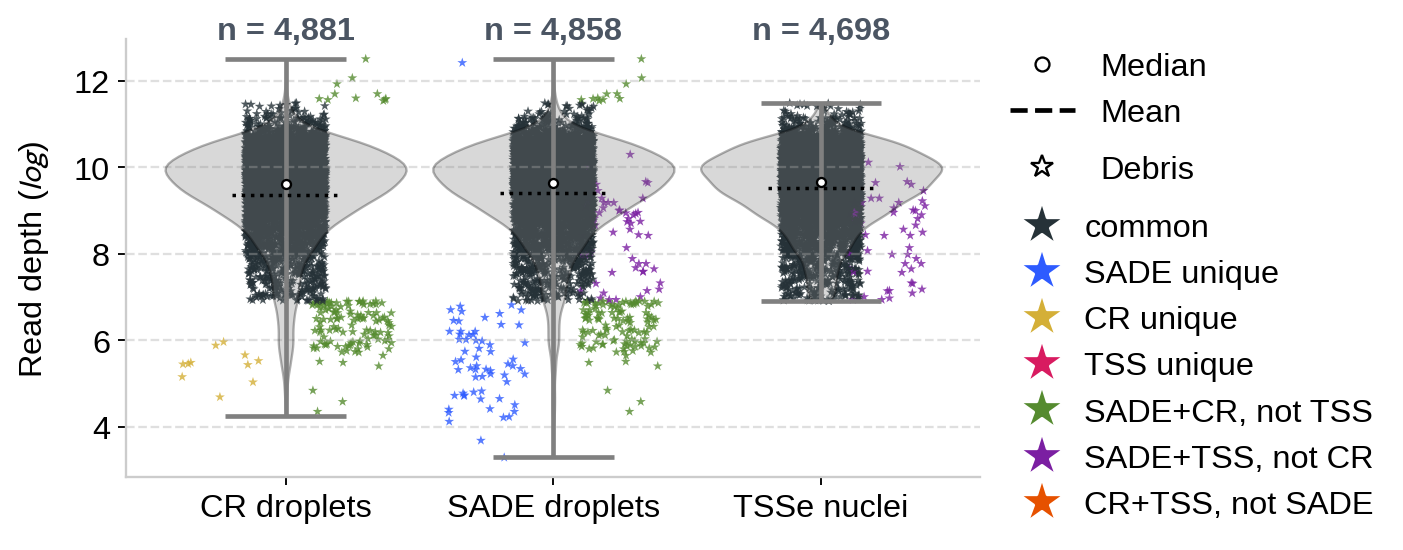

In [24]:

np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

read_depth_list = [union_cell_info.loc[union_cell_info[set_name], 'log_total_fragments'] for set_name in filtering_set]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_colors_map) for set_name in filtering_set]
jitter_position_offset = [union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_position_map) for set_name in filtering_set]
DNA_debris_flag = [union_cell_info.loc[union_cell_info[set_name], 'DNA_debris'] for set_name in filtering_set ]


total_counts = [len(a) for a in read_depth_list]
x_positions = np.arange(len(read_depth_list))


v1 = ax.violinplot(read_depth_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=False, showextrema=True)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for i, group_data in enumerate(read_depth_list):
    # For non-Multiplets cells, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=0.8, s = 20)
    # For Multiplets droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.6, jitter_width=0.15, alpha=1, s=20)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(read_depth_list):
    min, median, max = np.percentile(group_data, [0,  50,  100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.2, x_positions[i] + 0.2, color='black', linestyle=':', lw=1.5, alpha=1, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=1)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in filtering_set], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('Read depth ($log$)', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
leg1 = ax.legend(handles=legend_elements, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.73))
ax.add_artist(leg1) 

droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Debris', markersize=10) ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.6) )
ax.add_artist(leg2)  # Add the second legend back to the axes
handles =[Line2D([0], [0], marker='*', color='w', label=cat_labels_map[c],
                          markerfacecolor=cat_colors_map[c], markersize=20) for c in cat_colors_map.keys()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 0.67), loc='upper left', ncol=1, handletextpad=0.3)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  " + "\t".join(['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))

# FRIP score

In [25]:
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,Entropy,DNA_debris,P_closed_state,log_entropy,log_total_fragments,Nfrag_in_rawpeaks,frip_rawpeaks,_2set_identified_by_atac_SC_mod
atac_barcodes,,,,,,,,,,,,,,,
AAACAGCCAACCGCCA-1,19211,True,True,True,both,both,common,0.406097,NO,0.918889,-1.300103,9.863290,9359,0.487169,both
AAACAGCCAAGGTCGA-1,10802,True,True,True,both,both,common,0.415202,NO,0.916268,-1.268113,9.287579,5272,0.488058,both


-----   atac_pass_CR]  [atac_pass_entropy]  [atac_pass_archr_TSS
mean 	 ['0.488  ', '0.479  ', '0.481  ']
median 	 ['0.485  ', '0.482  ', '0.482  ']


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


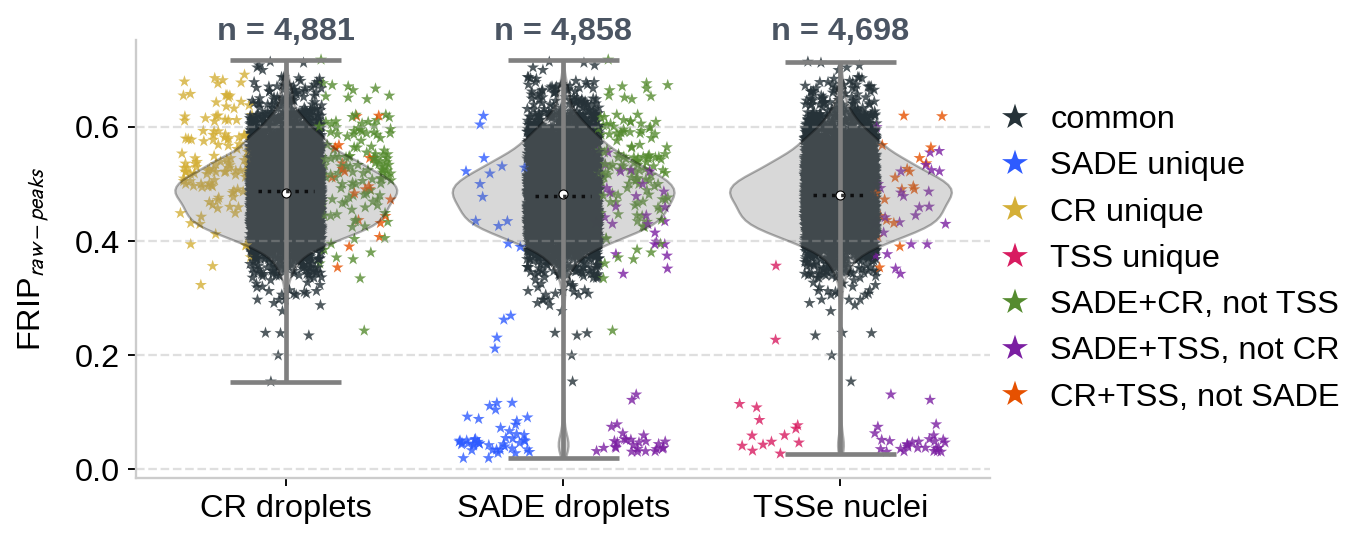

In [26]:
np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

frip_values = [ union_cell_info.loc[union_cell_info[set_name], 'frip_rawpeaks'] for set_name in filtering_set ]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_colors_map) for set_name in filtering_set]
jitter_position_offset = [
    union_cell_info.loc[union_cell_info[set_name], '_3set_identified_by_atac'].map(cat_position_map) for set_name in filtering_set
]

x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i] + jitter_position_offset[i], color=this_colors_list[i], alpha=0.8, s=30, jitter_width=0.13)

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.8, 
              showmedians=False, showmeans=False, 
              showextrema=True)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for met in ['cbars', 'cmins', 'cmaxes']:
     v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(frip_values):
    min, median, max = np.percentile(group_data, [0, 50, 100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle=':', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in filtering_set], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('FRIP$_{raw-peaks}$', labelpad=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
# leg1 = ax.legend(handles=legend_elements, loc='lower left', frameon=False, bbox_to_anchor=(1, 0.73))
# ax.add_artist(leg1)

ax.legend(handles=[Line2D([0], [0], marker='*', color='w', label=cat_labels_map[c],
                          markerfacecolor=cat_colors_map[c], markersize=15) for c in cat_colors_map.keys()],
             frameon=False, bbox_to_anchor=(1.2, 0.5), loc='center', ncol=1,  handletextpad=0.1)

mean_frip_values = [f'{np.mean(a):.3f}  ' for a in frip_values]
median_frip_values = [f'{np.median(a):.3f}  ' for a in frip_values]
print('-----   ' + ']  ['.join(filtering_set))
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# P(closed-state)

-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE
mean 	 ['0.068  ', '0.067  ', '0.069  ']
median 	 ['0.066  ', '0.066  ', '0.067  ']


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


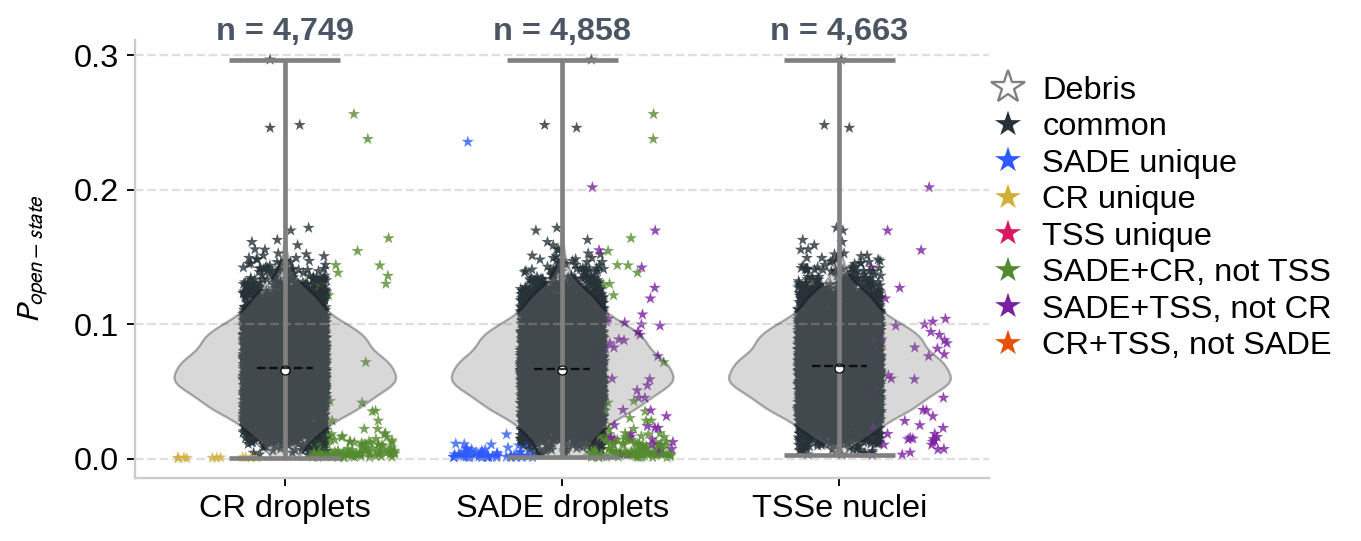

In [27]:
np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

Valid_entropy_cells = union_cell_info.loc[union_cell_info['P_closed_state'].notna()]

p_closed_state_values = [ 1 - Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'P_closed_state'] for set_name in filtering_set ]
this_colors_list = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_3set_identified_by_atac'].map(cat_colors_map) for set_name in filtering_set]
jitter_position_offset = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_3set_identified_by_atac'].map(cat_position_map) for set_name in filtering_set]
DNA_debris_flag = [     Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'DNA_debris'] for set_name in filtering_set ]

x_positions = range(len(p_closed_state_values))

for i, group_data in enumerate(p_closed_state_values):
    # For non-Multiplets cells, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=0.8, s=30)
    # For Multiplets droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.4, jitter_width=0.15, alpha=1, s=20)

v1 = ax.violinplot( [v.dropna() for v in p_closed_state_values], positions=x_positions, widths=0.8, 
              showmedians=False, showmeans=False, showextrema=True)

for met in ['cbars', 'cmins', 'cmaxes']:
     v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(p_closed_state_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

total_counts = [ p_closed_state.shape[0] for p_closed_state in p_closed_state_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in filtering_set], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('$P_{open-state}$', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')


droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15),
                  ]
droplet_handles+=[Line2D([0], [0], marker='*', color='w', label=cat_labels_map[c],
                          markerfacecolor=cat_colors_map[c], markersize=15) for c in cat_colors_map.keys()]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.95, 0.2), labelspacing=.2 , handletextpad=0.05)


mean_p_closed_state_values = [f'{np.mean(a):.3f}  ' for a in p_closed_state_values]
median_p_closed_state_values = [f'{np.median(a):.3f}  ' for a in p_closed_state_values]
print('-----   ' + ']  ['.join(cat_labels_map))
print(f'mean \t {mean_p_closed_state_values}')
print(f'median \t {median_p_closed_state_values}')

# 2 Set comparison

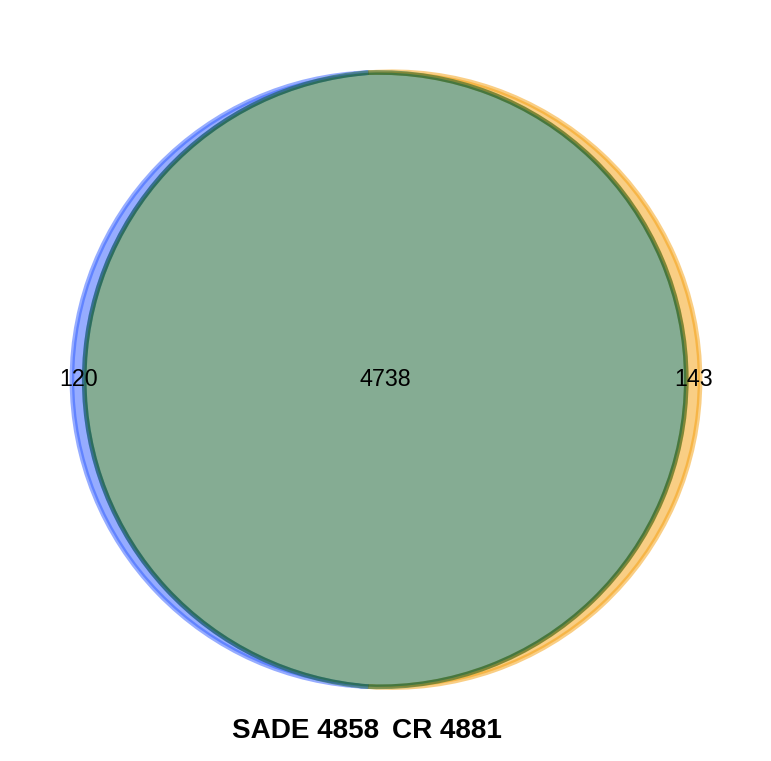

In [28]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    )

fig, ax = plt.subplots()

v = venn2(
    venn_sets[:2], 
                set_labels = (f'SADE {len(venn_sets[0])}',f'CR {len(venn_sets[1])}'), 
                set_colors = ( 'blue', 'orange'), 
                ax = ax)


set_colors = ("#64B1CB", "#D4C645", "#0C5B28")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = v.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width


v.get_patch_by_id('10').set_color('#2E5BFF') # Set A
v.get_patch_by_id('01').set_color('#F59E0B') # Set B
v.get_patch_by_id('11').set_color('#0C5B28') # Set C


for patch in v.patches:
    if patch: # Some patches might be None if subsets are empty
        patch.set_alpha(.5)

# Change font size of subset counts
for text in v.subset_labels:
    if text: # Check if label exists
        text.set_fontsize(10)

# Change font size of Set Labels (A, B, C)
for text in v.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

for label in ['10', '01', '11']:
    vl = v.get_label_by_id(label)
    x, y = vl.get_position()
    vl.set_position((x * 1, y * 1.05 ))
    # elif label in ['110',  '101']:  # Double sets
    #     vl.set_position((x * 1.2, y * 1.1))
    # elif label == '011':  # B & C
    #     vl.set_position((x * 1.1, y * 0.9))

fig.tight_layout()

fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p1.pdf'))
fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p1.png'), dpi=300)

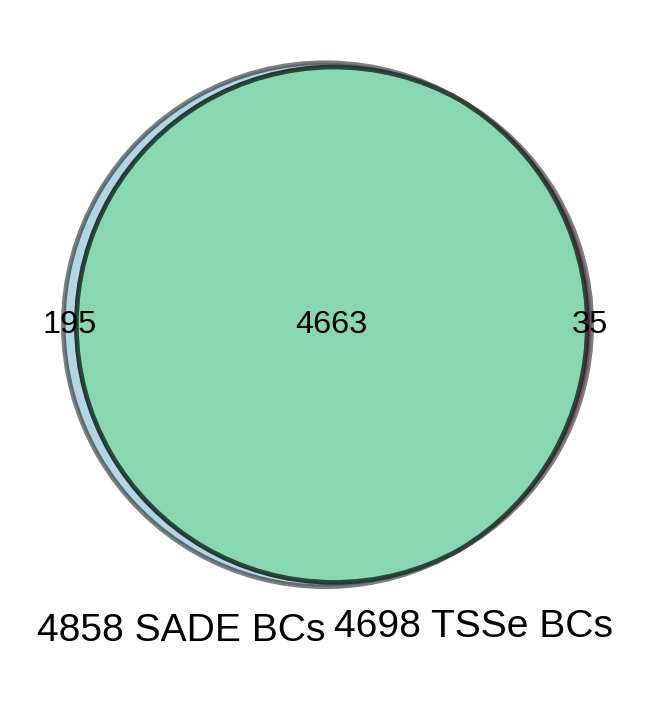

In [29]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    )


fig1, ax1 = plt.subplots()

vennfig = venn2(
    venn_sets[:2], 
                set_labels = (f'{len(venn_sets[0])} SADE BCs\n',f'{len(venn_sets[1])} TSSe BCs\n'), 
                ax = ax1)

set_colors = ('#ADD8E6', '#FFFFE0', '#FFB6C1') 
set_colors = ("#64B1CB", "#D67022", "#0C5B28")  
set_colors = ("#64B1CB", "#EC4899", "#13B062")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = vennfig.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width

# plt.title('SADE vs TSS', fontsize=16)


/tmp/ipykernel_4184596/494100821.py:40: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p2.pdf'), bbox_inches='tight')
/tmp/ipykernel_4184596/494100821.py:41: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p2.png'), dpi=300, bbox_inches='tight')
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(by

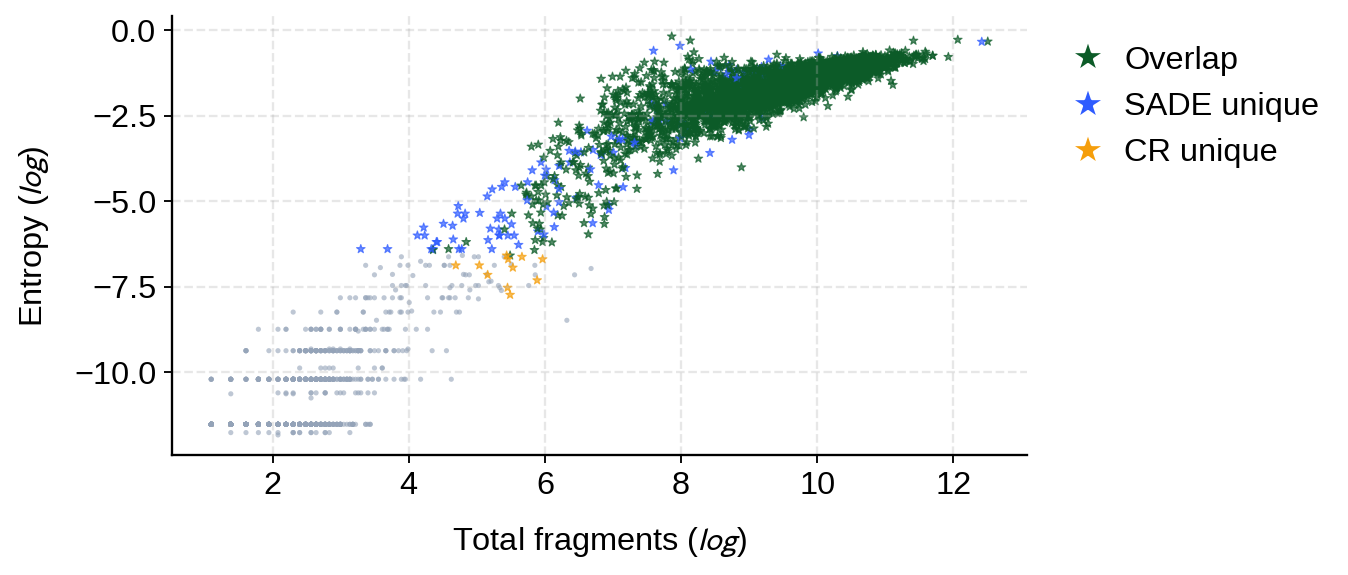

In [30]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])


none_index = entropy_df['_2set_identified_by_atac_SC'] == 'none'
permitted_index = ~none_index
v = ax.scatter( entropy_df.loc[none_index]['log_total_fragments'], entropy_df.loc[none_index]['log_entropy'] ,  
            c= entropy_df.loc[none_index]['_2set_identified_by_atac_SC'].map(SADEvsCR_colors_map),
            alpha=0.6,
            marker='o', 
                s=5,          
                lw=0,         
                rasterized=True # Keeps the file size light if saving to PDF
                        )


ax.scatter( entropy_df.loc[permitted_index]['log_total_fragments'], entropy_df.loc[permitted_index]['log_entropy'] ,  
            c= entropy_df.loc[permitted_index]['_2set_identified_by_atac_SC'].map(SADEvsCR_colors_map),
            alpha=0.7,
            marker='*', 
                s=15,          
                lw=0.5,         
                rasterized=True # Keeps the file size light if saving to PDF
                        )

# 4. Clean up the Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)', labelpad=10)
ax.set_ylabel('Entropy ($log$)', labelpad=10)
# ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)

handles = [Line2D([0], [0], marker='*', color='w', markerfacecolor=SADEvsCR_colors_map[c], label=SADEvsCR_label_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ( 'none', 'tss_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.1)

fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p2.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p2.png'), dpi=300, bbox_inches='tight')


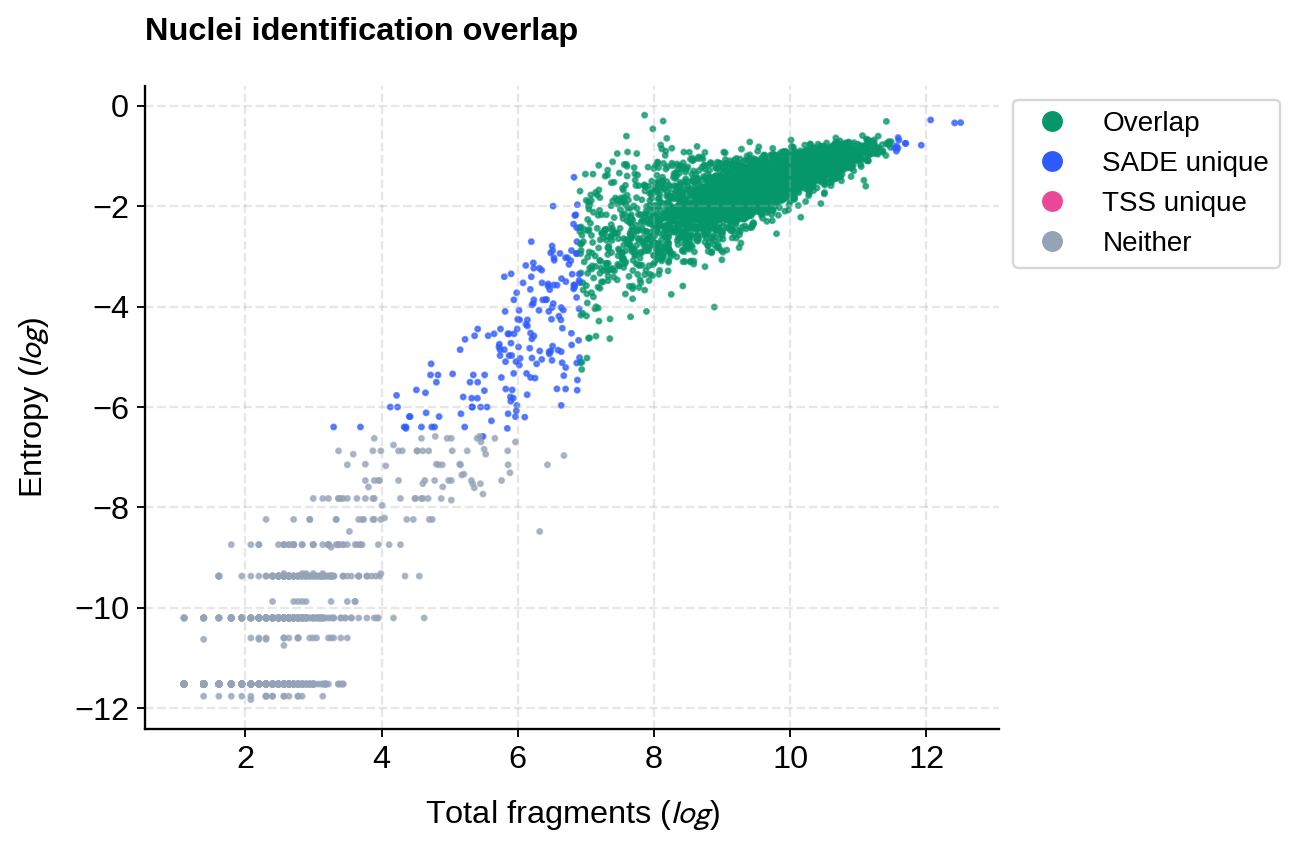

In [31]:
fig, ax = plt.subplots( figsize=(6.6, 5) )

twosets_colors_map = {'both':"#059669", 'entropy_only':'#2E5BFF', 'tss_only':"#EC4899", 'none':'#94A3B8'}
twosets_labels_map = {'both':'Overlap', 'entropy_only':'SADE unique', 'tss_only':'TSS unique', 'none':'Neither'}
ax.scatter( entropy_df['log_total_fragments'], entropy_df['log_entropy'],  c= entropy_df['_2set_identified_by_atac_ST'].map(twosets_colors_map), 
            alpha=0.7, 
            s=4,          
            lw=1,         
            rasterized=True # Keeps the file size light if saving to PDF
                )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)', labelpad=10)
ax.set_ylabel('Entropy ($log$)', labelpad=10)
ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)


handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in twosets_colors_map.items()]

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=twosets_labels_map[c],
                          markerfacecolor=twosets_colors_map[c], markersize=10) for c in twosets_colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=12)


plt.show()

_3set_identified_by_atac
CR unique           112
CR+TSS, not SADE     20
TSS unique           15
Name: count, dtype: int64
                          count      mean       std       min       25%  \
_3set_identified_by_atac                                                  
CR unique                 112.0  0.539079  0.074030  0.323077  0.497744   
CR+TSS, not SADE           20.0  0.495544  0.071295  0.353774  0.442145   
TSS unique                 15.0  0.093319  0.088054  0.027536  0.044963   

                               50%       75%       max  
_3set_identified_by_atac                                
CR unique                 0.534843  0.582708  0.691667  
CR+TSS, not SADE          0.493488  0.538622  0.619772  
TSS unique                0.059589  0.097441  0.356836  


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


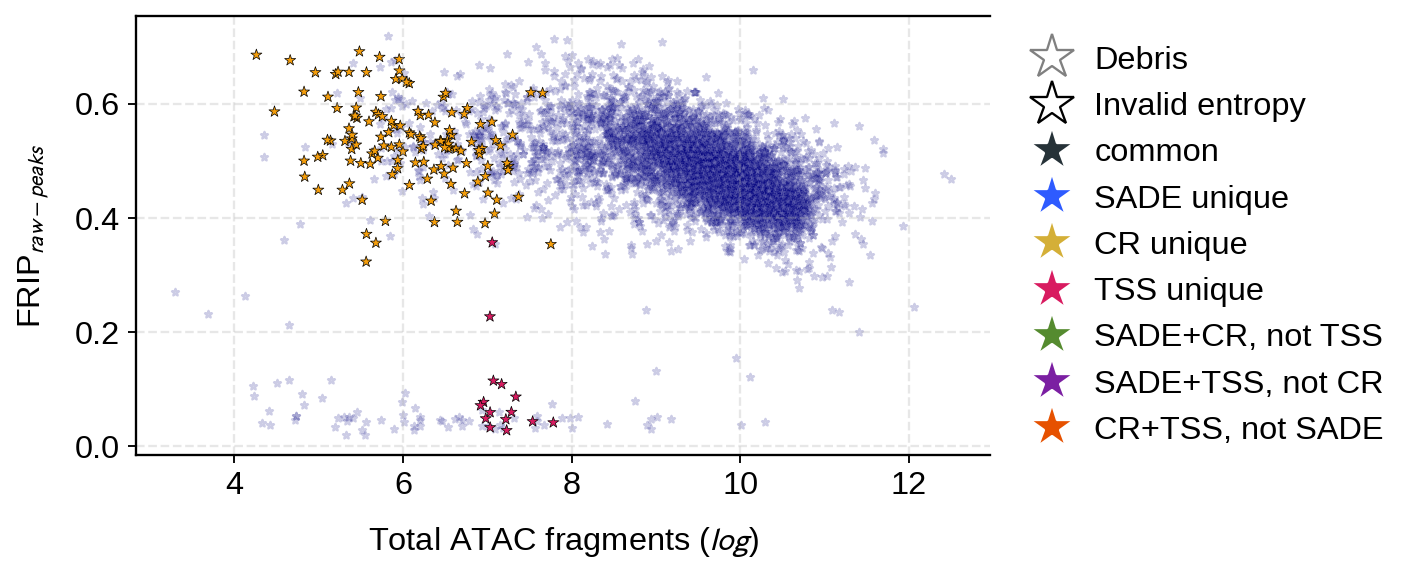

In [32]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

dna_debris_index = union_cell_info['DNA_debris'] == 'YES'
invalid_entropy_index = union_cell_info['Entropy'].isna()

# Only the droplets in the union set are colored by their category 
## For non-DNA-debris droplets, color by their category
ax.scatter( union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'log_total_fragments'], union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'frip_rawpeaks'],  edgecolors= 'navy', 
            c='white', alpha=0.2, 
            s=10,          
            lw=1,      
            marker='*', 
              
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For invalid droplets, edgecolor in grey
ax.scatter( union_cell_info.loc[dna_debris_index, 'log_total_fragments'], union_cell_info.loc[dna_debris_index, 'frip_rawpeaks'],  c= union_cell_info.loc[dna_debris_index, '_2set_identified_by_atac_SC_mod'].map(cat_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.5,      
            marker='*',   
            edgecolors='grey',
            rasterized=True # Keeps the file size light if saving to PDF
                )
## For droplets with invalid entropy, edgecolor in red 
ax.scatter( union_cell_info.loc[invalid_entropy_index, 'log_total_fragments'], union_cell_info.loc[invalid_entropy_index, 'frip_rawpeaks'],  c= union_cell_info.loc[invalid_entropy_index, '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map), 
            alpha=1, 
            s=25,          
            lw=0.3,      
            marker='*',   
            edgecolors='black',
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log$)', labelpad=10)
ax.set_ylabel('FRIP$_{raw-peaks}$', labelpad=10)


handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none',  label='Debris', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none',  label='Invalid entropy', markersize=20)]
handles += [Line2D([0], [0], marker='*', color='w', markerfacecolor=v, label=k, markersize=20) for k, v in cat_colors_map.items()]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1, 1), loc='upper left', ncol=1, handletextpad=0.3)

print(
union_cell_info.loc[invalid_entropy_index, '_3set_identified_by_atac'].value_counts()
)
print(
union_cell_info.loc[invalid_entropy_index].groupby('_3set_identified_by_atac')['frip_rawpeaks'].describe()
)

## Emphasize on comparison between SADE vs CR, then added on TSSe unique barcodes 

/tmp/ipykernel_4184596/3796620998.py:66: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p3.pdf'), bbox_inches='tight')
/tmp/ipykernel_4184596/3796620998.py:67: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p3.png'), dpi=300, bbox_inches='tight')
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)


-----------------------------------------
------  atac_pass_CR	atac_pass_entropy	atac_pass_archr_TSS
Mean:  9.4	9.4
Median: 9.622714888385282	9.628392593422841


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


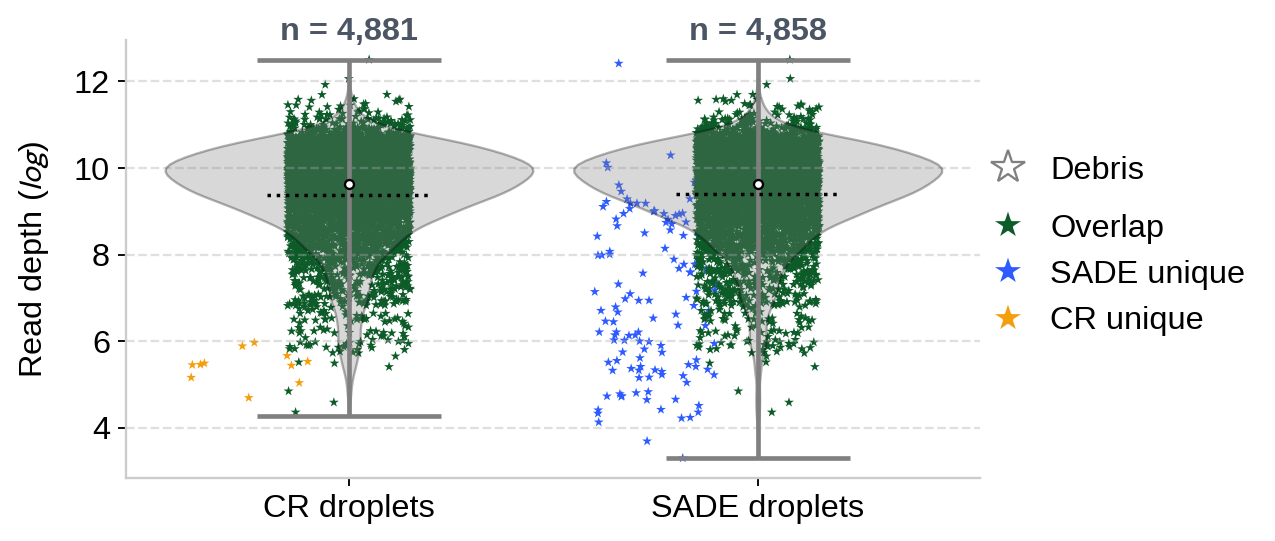

In [33]:

np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

read_depth_list = [union_cell_info.loc[union_cell_info[set_name], 'log_total_fragments'] for set_name in SADEvsCR_filteringset]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for set_name in SADEvsCR_filteringset]
jitter_position_offset = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for set_name in SADEvsCR_filteringset]
DNA_debris_flag = [union_cell_info.loc[union_cell_info[set_name], 'DNA_debris'] for set_name in SADEvsCR_filteringset ]


total_counts = [len(a) for a in read_depth_list]
x_positions = np.arange(len(read_depth_list))


v1 = ax.violinplot(read_depth_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=False, showextrema=True)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for i, group_data in enumerate(read_depth_list):
    # For non-Multiplets cells, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=1, s = 20, lw=1)
    # For Multiplets droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.5, jitter_width=0.15, alpha=1, s=20)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(read_depth_list):
    min, median, max = np.percentile(group_data, [0,  50,  100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.2, x_positions[i] + 0.2, color='black', linestyle=':', lw=1.5, alpha=1, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=1)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in SADEvsCR_filteringset], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('Read depth ($log$)', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')



droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15) ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.96, 0.6) ,handletextpad=0.3)
ax.add_artist(leg2)  # Add the second legend back to the axes
handles =[Line2D([0], [0], marker='*', color='w', label=SADEvsCR_label_map[c],
                          markerfacecolor=SADEvsCR_colors_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ('none', 'tss_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(0.96, 0.67), loc='upper left', ncol=1, handletextpad=0.3)

fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p3.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p3.png'), dpi=300, bbox_inches='tight')


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  " + "\t".join(['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)


-----------------------------------------
------  atac_pass_CR	atac_pass_entropy	atac_pass_archr_TSS
Mean:  9.4	9.4
Median: 9.622714888385282	9.628392593422841


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


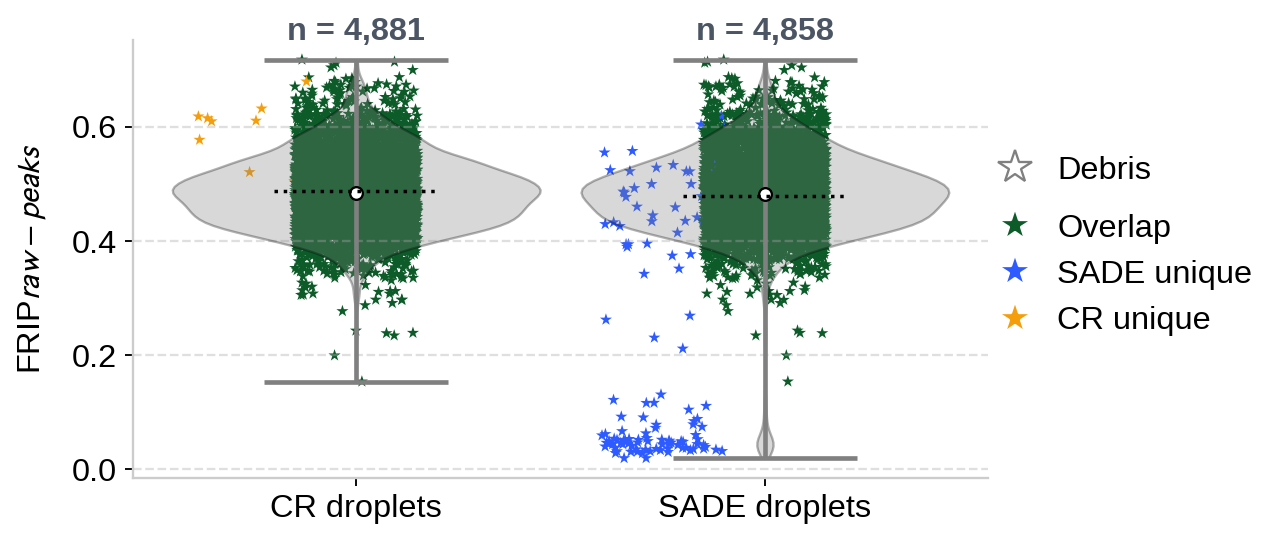

In [34]:

np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

frip_list = [union_cell_info.loc[union_cell_info[set_name], 'frip_rawpeaks'] for set_name in SADEvsCR_filteringset]
this_colors_list = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for set_name in SADEvsCR_filteringset]
jitter_position_offset = [union_cell_info.loc[union_cell_info[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for set_name in SADEvsCR_filteringset]
DNA_debris_flag = [union_cell_info.loc[union_cell_info[set_name], 'DNA_debris'] for set_name in SADEvsCR_filteringset ]


total_counts = [len(a) for a in frip_list]
x_positions = np.arange(len(frip_list))


v1 = ax.violinplot(frip_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=False, showextrema=True)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

for i, group_data in enumerate(frip_list):
    # For non-debris droplets, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors='none', jitter_width=0.15, alpha=1, s = 30, lw=1)
    # For debris droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.4, jitter_width=0.15, alpha=1, s=30)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(frip_list):
    min, median, max = np.percentile(group_data, [0,  50,  100])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.2, x_positions[i] + 0.2, color='black', linestyle=':', lw=1.5, alpha=1, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=30, zorder=3, edgecolor='black', lw=1)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in SADEvsCR_filteringset], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('FRIP$raw-peaks$', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')



droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15) ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.96, 0.6) , handletextpad=0.3)
ax.add_artist(leg2)  # Add the second legend back to the axes
handles =[Line2D([0], [0], marker='*', color='w', label=SADEvsCR_label_map[c],
                          markerfacecolor=SADEvsCR_colors_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ('none', 'tss_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(0.96, 0.67), loc='upper left', ncol=1, handletextpad=0.3)


mean_read_depth = [a.mean() for a in read_depth_list]
median_read_depth = [a.median() for a in read_depth_list]
print(f"-----------------------------------------")
print(f"------  " + "\t".join(['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS']))
print(f"Mean:  " + "\t".join([f"{mean:.1f}" for mean in mean_read_depth]))
print(f"Median: " + "\t".join([f"{median}" for median in median_read_depth]))

/tmp/ipykernel_4184596/3301673669.py:63: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p4.pdf'), bbox_inches='tight')
/tmp/ipykernel_4184596/3301673669.py:64: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p4.png'), dpi=300, bbox_inches='tight')


-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE
mean 	 ['0.068  ', '0.067  ']
median 	 ['0.066  ', '0.066  ']


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


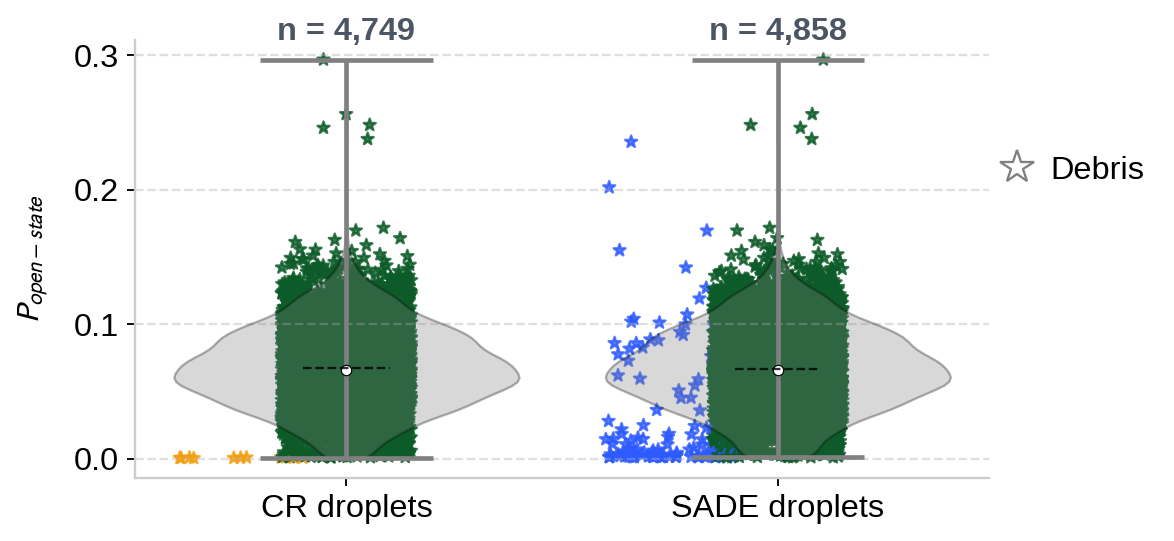

In [35]:
np.random.seed(999) # For reproducibility of jitter
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax = plt.subplot(gs[1])

Valid_entropy_cells = union_cell_info.loc[union_cell_info['P_closed_state'].notna()]

p_closed_state_values = [ 1 - Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'P_closed_state'] for set_name in SADEvsCR_filteringset ]
this_colors_list = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for set_name in SADEvsCR_filteringset]
jitter_position_offset = [Valid_entropy_cells.loc[Valid_entropy_cells[set_name], '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for set_name in SADEvsCR_filteringset]
DNA_debris_flag = [     Valid_entropy_cells.loc[Valid_entropy_cells[set_name], 'DNA_debris'] for set_name in SADEvsCR_filteringset ]

x_positions = range(len(p_closed_state_values))

for i, group_data in enumerate(p_closed_state_values):
    # For non-debris droplets, add jittered points
    debris_index = (DNA_debris_flag[i] == 'YES')
    no_debris_index = (DNA_debris_flag[i] == 'NO')
    add_jittered_points(ax, group_data[no_debris_index], x_positions[i] + jitter_position_offset[i][no_debris_index], color=this_colors_list[i][no_debris_index], 
                        edgecolors=this_colors_list[i][no_debris_index], jitter_width=0.15, alpha=0.8, s=30)
    # For debris droplets 
    add_jittered_points(ax, group_data[debris_index], x_positions[i] + jitter_position_offset[i][debris_index], color=this_colors_list[i][debris_index], 
                        edgecolors='grey', lw=0.6, jitter_width=0.15, alpha=1, s=30)

v1 = ax.violinplot( [v.dropna() for v in p_closed_state_values], positions=x_positions, widths=0.8, 
              showmedians=False, showmeans=False, showextrema=True)

for met in ['cbars', 'cmins', 'cmaxes']:
     v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(p_closed_state_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=20, zorder=3, edgecolor='black', lw=0.5)

total_counts = [ p_closed_state.shape[0] for p_closed_state in p_closed_state_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            color='#4B5563', fontweight='bold')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels([filtering_set_label_map[set_name] for set_name in SADEvsCR_filteringset], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('$P_{open-state}$', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')


droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='grey', markerfacecolor='none', label='Debris', markersize=15),
                  ]
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.96, 0.6), labelspacing=.2 , handletextpad=0.05)

fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p4.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p4.png'), dpi=300, bbox_inches='tight')


mean_p_closed_state_values = [f'{np.mean(a):.3f}  ' for a in p_closed_state_values]
median_p_closed_state_values = [f'{np.median(a):.3f}  ' for a in p_closed_state_values]
print('-----   ' + ']  ['.join(cat_labels_map))
print(f'mean \t {mean_p_closed_state_values}')
print(f'median \t {median_p_closed_state_values}')

/tmp/ipykernel_4184596/1171569276.py:57: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p5.pdf'), bbox_inches='tight')
/tmp/ipykernel_4184596/1171569276.py:58: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p5.png'), dpi=300, bbox_inches='tight')
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(

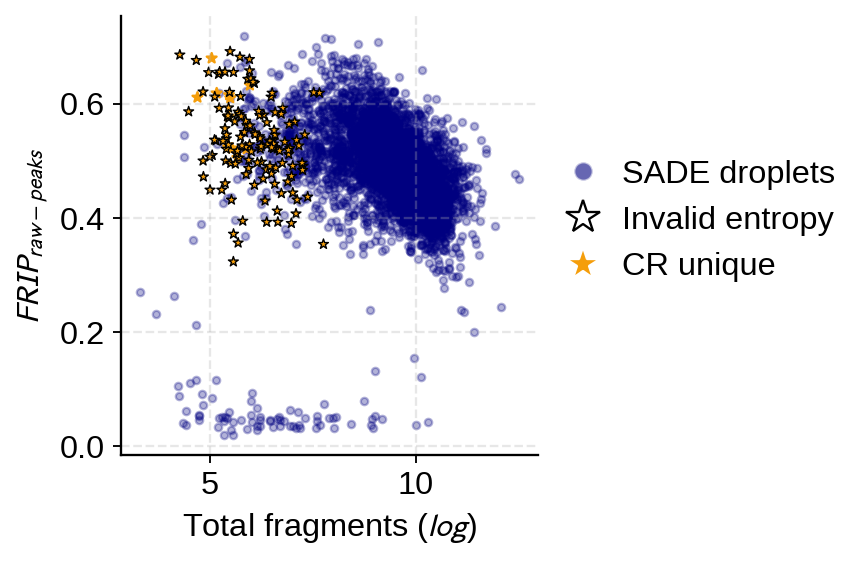

In [36]:
fig= plt.figure(layout='constrained', figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

gs1 = gs[1].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.05)
ax = plt.subplot(gs1[1])


not_in_entropy_set = ~union_cell_info['atac_pass_entropy']
in_cr_set = union_cell_info['atac_pass_CR']
invalid_entropy_set = union_cell_info['Entropy'].isna()
# SADE droplets 
ax.scatter( union_cell_info.loc[ (~not_in_entropy_set) , 'log_total_fragments'], union_cell_info.loc[(~not_in_entropy_set) , 'frip_rawpeaks'],  c= 'navy',
            alpha=0.3, 
            s=10,          
            lw=1,      
            marker='o',   
            rasterized=True # Keeps the file size light if saving to PDF
                )
# not in SADE but valid entropy values among CR droplets
ax.scatter( union_cell_info.loc[not_in_entropy_set & in_cr_set & (~invalid_entropy_set) , 'log_total_fragments'], 
            union_cell_info.loc[not_in_entropy_set & in_cr_set & (~invalid_entropy_set), 'frip_rawpeaks'], 
            c=union_cell_info.loc[not_in_entropy_set & in_cr_set & (~invalid_entropy_set), '_2set_identified_by_atac_SC'].map(SADEvsCR_colors_map),
            marker='*', 
            s=20,
            alpha=1,
            lw=1,)
# not in SADE and invalid entropy values among CR droplets, (edgecolor in black)
ax.scatter( union_cell_info.loc[not_in_entropy_set & in_cr_set & invalid_entropy_set, 'log_total_fragments'], union_cell_info.loc[not_in_entropy_set & in_cr_set & invalid_entropy_set, 'frip_rawpeaks'], 
           c=union_cell_info.loc[not_in_entropy_set & in_cr_set & (invalid_entropy_set), '_2set_identified_by_atac_SC'].map(SADEvsCR_colors_map),
           edgecolors='black',
           #c='black',
            alpha=1, 
            s=20,          
            lw=0.6,      
            marker='*',   
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total fragments ($log$)')
ax.set_ylabel('$FRIP_{raw-peaks}$')

# droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Invalid entropy', markersize=15),]
# leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, bbox_to_anchor=(0.96, 0.65), handletextpad=0.2 )
# ax.add_artist(leg2)  

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='navy', label='SADE droplets', markersize=8, alpha=0.6)] 
handles += [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='Invalid entropy', markersize=15),]
handles += [Line2D([0], [0], marker='*', color='w', label=SADEvsCR_label_map[c],
                          markerfacecolor=SADEvsCR_colors_map[c], markersize=15) for c in SADEvsCR_unique_categoris if c not in ('none', 'tss_only', 'both', 'entropy_only')]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(0.96, 0.74), loc='upper left', ncol=1, handletextpad=0.2)

fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p5.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures',  'fig2_p5.png'), dpi=300, bbox_inches='tight')